# Identificacion de patrones de consumo energetico con aprendizaje no supervisado

En este proyecto se usa inteligencia artificial para analizar patrones de consumo electrico dentro del sistema regional PJM Interconnection.

A diferencia del proyecto anterior, aqui no se busca predecir un valor exacto de consumo. El objetivo es agrupar dias con comportamientos similares para identificar patrones de consumo normal, alta demanda, bajo consumo o posibles comportamientos atipicos.

El enfoque usado es **aprendizaje no supervisado**, porque el modelo no recibe una respuesta correcta ni una etiqueta previa. El algoritmo debe descubrir grupos ocultos directamente a partir de los datos.


## 1. Introduccion

Las empresas electricas manejan grandes cantidades de datos historicos de consumo. Estos datos pueden mostrar patrones importantes, como dias con demanda normal, dias con consumo alto, dias de bajo consumo o dias con comportamientos poco comunes.

El sistema PJM Interconnection es una organizacion regional de transmision electrica de Estados Unidos. El dataset contiene registros horarios asociados al consumo electrico dentro de este sistema.

En este notebook se prepara la informacion horaria, se resume por dia y se aplica K-Means Clustering para encontrar grupos de dias parecidos.


## 2. Problematica

Revisar manualmente miles de registros horarios de consumo electrico es dificil y poco eficiente. Cuando una empresa electrica no identifica a tiempo patrones de alta demanda o comportamientos atipicos, puede tener problemas de planeacion y operacion.

Detectar automaticamente dias de alta demanda, baja demanda o comportamiento anormal puede ayudar a:

- Planear mejor la produccion y distribucion de energia.
- Preparar recursos de respaldo.
- Analizar picos de consumo.
- Apoyar la toma de decisiones operativas.


## 3. Solucion con IA

La solucion propuesta usa aprendizaje no supervisado para agrupar dias con patrones similares de consumo energetico.

El modelo no conoce previamente si un dia fue normal, alto, bajo o atipico. En lugar de eso, analiza variables diarias como consumo promedio, consumo maximo, consumo minimo, consumo total, rango de consumo, desviacion y hora pico.

Con esas variables, K-Means separa los dias en grupos llamados clusters. Luego se interpretan esos grupos revisando los valores promedio de cada cluster.


## 4. Que intenta hacer el modelo

En este proyecto no se predice un valor exacto. El modelo intenta **agrupar dias** con patrones similares de consumo energetico.

La salida del modelo es un numero de cluster para cada dia. Despues, cada cluster se interpreta como consumo normal, alta demanda, bajo consumo o comportamiento atipico.


In [1]:
import pandas as pd
from IPython.display import display

objetivo_no_supervisado = pd.DataFrame({
    'Elemento': ['Tipo de aprendizaje', 'Algoritmo', 'Entrada del modelo', 'Salida del modelo'],
    'Descripcion': [
        'Aprendizaje no supervisado',
        'K-Means Clustering',
        'Variables diarias de consumo energetico',
        'Cluster asignado a cada dia'
    ]
})

display(objetivo_no_supervisado)


,Elemento,Descripcion
0,Tipo de aprendizaje,Aprendizaje no supervisado
1,Algoritmo,K-Means Clustering
2,Entrada del modelo,Variables diarias de consumo energetico
3,Salida del modelo,Cluster asignado a cada dia


## 4. Importar librerias

Se importan las librerias necesarias para cargar datos, preparar variables, normalizar, entrenar K-Means, evaluar los clusters y crear graficas.


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)


## 5. Cargar el dataset

Se carga el archivo `dataset/pjm_hourly_est.csv`. Este archivo contiene registros historicos por hora del consumo electrico dentro del sistema PJM.

Algunas columnas representan zonas del sistema y la columna `PJM_Load` representa la carga total estimada del sistema. Para este proyecto se usa `PJM_Load` como base para construir los patrones diarios de consumo.


In [3]:
rutas_posibles = [
    Path('dataset/pjm_hourly_est.csv'),
    Path('../dataset/pjm_hourly_est.csv')
]

ruta_dataset = next((ruta for ruta in rutas_posibles if ruta.exists()), None)

if ruta_dataset is None:
    raise FileNotFoundError('No se encontro el archivo dataset/pjm_hourly_est.csv')

df = pd.read_csv(ruta_dataset)

print(f'Archivo cargado: {ruta_dataset}')
display(df.head())


Archivo cargado: ..\dataset\pjm_hourly_est.csv


,Datetime,AEP,COMED,DAYTON,DEOK,DOM,DUQ,EKPC,FE,NI,PJME,PJMW,PJM_Load
0,1998-12-31 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29309.0
1,1998-12-31 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28236.0
2,1998-12-31 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27692.0
3,1998-12-31 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27596.0
4,1998-12-31 05:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27888.0


## 6. Informacion general del dataset

Antes de preparar los datos, se revisa la estructura general del archivo. Esto permite conocer columnas, tipos de datos, estadisticas basicas y valores nulos.


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 178262 entries, 0 to 178261
Data columns (total 13 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  178262 non-null  str    
 1   AEP       121273 non-null  float64
 2   COMED     66497 non-null   float64
 3   DAYTON    121275 non-null  float64
 4   DEOK      57739 non-null   float64
 5   DOM       116189 non-null  float64
 6   DUQ       119068 non-null  float64
 7   EKPC      45334 non-null   float64
 8   FE        62874 non-null   float64
 9   NI        58450 non-null   float64
 10  PJME      145366 non-null  float64
 11  PJMW      143206 non-null  float64
 12  PJM_Load  32896 non-null   float64
dtypes: float64(12), str(1)
memory usage: 17.7 MB


In [5]:
display(df.describe())


,AEP,COMED,DAYTON,DEOK,DOM,DUQ,EKPC,FE,NI,PJME,PJMW,PJM_Load
count,121273.000000,66497.000000,121275.000000,57739.000000,116189.000000,119068.000000,45334.000000,62874.000000,58450.000000,145366.000000,143206.000000,32896.000000
mean,15499.513717,11420.152112,2037.851140,3105.096486,10949.203625,1658.820296,1464.218423,7792.159064,11701.682943,32080.222831,5602.375089,29766.427408
std,2591.399065,2304.139517,393.403153,599.859026,2413.946569,301.740640,378.868404,1331.268006,2371.498701,6464.012166,979.142872,5849.769954
min,9581.000000,7237.000000,982.000000,907.000000,1253.000000,1014.000000,514.000000,0.000000,7003.000000,14544.000000,487.000000,17461.000000
25%,13630.000000,9780.000000,1749.000000,2687.000000,9322.000000,1444.000000,1185.000000,6807.000000,9954.000000,27573.000000,4907.000000,25473.000000
50%,15310.000000,11152.000000,2009.000000,3013.000000,10501.000000,1630.000000,1386.000000,7700.000000,11521.000000,31421.000000,5530.000000,29655.000000
75%,17200.000000,12510.000000,2279.000000,3449.000000,12378.000000,1819.000000,1699.000000,8556.000000,12896.750000,35650.000000,6252.000000,33073.250000
max,25695.000000,23753.000000,3746.000000,5445.000000,21651.000000,3054.000000,3490.000000,14032.000000,23631.000000,62009.000000,9594.000000,54030.000000


In [6]:
valores_nulos = pd.DataFrame({
    'Columna': df.columns,
    'Valores nulos': df.isna().sum().values,
    'Porcentaje nulos': (df.isna().mean().values * 100).round(2)
})

display(valores_nulos)


,Columna,Valores nulos,Porcentaje nulos
0,Datetime,0,0.00
1,AEP,56989,31.97
2,COMED,111765,62.70
3,DAYTON,56987,31.97
4,DEOK,120523,67.61
5,DOM,62073,34.82
6,DUQ,59194,33.21
7,EKPC,132928,74.57
8,FE,115388,64.73
9,NI,119812,67.21


## 7. Limpieza y preparacion de datos

Para trabajar con datos horarios es necesario convertir la fecha a formato `datetime`, ordenar los registros por tiempo y asegurar que las columnas numericas esten en formato correcto.

En este proyecto se trabaja con la columna `PJM_Load`, porque representa la carga total estimada del sistema PJM. Luego se crean variables temporales y se agrupan los datos por dia.


In [7]:
datos = df.copy()

if 'Datetime' not in datos.columns:
    raise ValueError('El dataset debe contener la columna Datetime')

if 'PJM_Load' not in datos.columns:
    raise ValueError('El dataset debe contener la columna PJM_Load')

# Se convierte la fecha y la carga total.
datos['Datetime'] = pd.to_datetime(datos['Datetime'], errors='coerce')
datos['PJM_Load'] = pd.to_numeric(datos['PJM_Load'], errors='coerce')

# Se ordenan los registros por fecha.
datos = datos.sort_values('Datetime').reset_index(drop=True)


In [8]:
columnas_numericas = datos.select_dtypes(include='number').columns.tolist()

print('Columnas numericas encontradas:')
display(pd.DataFrame({'Columna numerica': columnas_numericas}))


Columnas numericas encontradas:


,Columna numerica
0,AEP
1,COMED
2,DAYTON
3,DEOK
4,DOM
5,DUQ
6,EKPC
7,FE
8,NI
9,PJME


In [9]:
# Se conservan registros con fecha y consumo validos.
datos_horarios = datos[['Datetime', 'PJM_Load']].dropna().copy()

# Se crean variables temporales.
datos_horarios['fecha'] = datos_horarios['Datetime'].dt.floor('D')
datos_horarios['hora'] = datos_horarios['Datetime'].dt.hour
datos_horarios['dia'] = datos_horarios['Datetime'].dt.day
datos_horarios['mes'] = datos_horarios['Datetime'].dt.month
datos_horarios['dia_semana'] = datos_horarios['Datetime'].dt.dayofweek

print('Registros horarios validos:', len(datos_horarios))
display(datos_horarios.head())


Registros horarios validos: 32896


,Datetime,PJM_Load,fecha,hora,dia,mes,dia_semana
0,1998-04-01 01:00:00,22259.0,1998-04-01,1,1,4,2
1,1998-04-01 02:00:00,21244.0,1998-04-01,2,1,4,2
2,1998-04-01 03:00:00,20651.0,1998-04-01,3,1,4,2
3,1998-04-01 04:00:00,20421.0,1998-04-01,4,1,4,2
4,1998-04-01 05:00:00,20713.0,1998-04-01,5,1,4,2


## 8. Crear el dataset diario

El dataset original esta por hora. Para agrupar dias completos, se crea un nuevo dataset diario.

Cada fila del nuevo dataset representa un dia y resume el comportamiento de consumo de ese dia mediante variables estadisticas.


In [10]:
resumen_diario = datos_horarios.groupby('fecha').agg(
    consumo_promedio=('PJM_Load', 'mean'),
    consumo_maximo=('PJM_Load', 'max'),
    consumo_minimo=('PJM_Load', 'min'),
    consumo_total=('PJM_Load', 'sum'),
    desviacion_consumo=('PJM_Load', 'std'),
    registros_dia=('PJM_Load', 'count')
).reset_index()

resumen_diario['rango_consumo'] = resumen_diario['consumo_maximo'] - resumen_diario['consumo_minimo']

indice_hora_pico = datos_horarios.groupby('fecha')['PJM_Load'].idxmax()
horas_pico = datos_horarios.loc[indice_hora_pico, ['fecha', 'hora']].rename(columns={'hora': 'hora_pico'})

datos_diarios = resumen_diario.merge(horas_pico, on='fecha', how='left')

# Se evitan dias con muy pocos registros.
datos_diarios = datos_diarios[datos_diarios['registros_dia'] >= 18].copy()
datos_diarios = datos_diarios.dropna().reset_index(drop=True)

print('Dias disponibles para el modelo:', len(datos_diarios))
display(datos_diarios.head())


Dias disponibles para el modelo: 1371


,fecha,consumo_promedio,consumo_maximo,consumo_minimo,consumo_total,desviacion_consumo,registros_dia,rango_consumo,hora_pico
0,1998-04-01,27813.739130,31636.0,20421.0,639716.0,4281.044968,23,11215.0,20
1,1998-04-02,26605.791667,30656.0,19675.0,638539.0,4064.977597,24,10981.0,20
2,1998-04-03,25672.333333,29065.0,19215.0,616136.0,3577.090616,24,9850.0,20
3,1998-04-04,24487.083333,28366.0,19364.0,587690.0,3181.655830,24,9002.0,20
4,1998-04-05,23487.565217,27354.0,20506.0,540214.0,1922.967471,23,6848.0,21


## 9. Variables para el aprendizaje no supervisado

Para aplicar K-Means se usan variables que describen el comportamiento diario del consumo energetico.

| Variable | Que representa | Por que ayuda |
|---|---|---|
| consumo_promedio | Promedio diario de consumo | Resume el nivel general del dia |
| consumo_maximo | Mayor consumo registrado en el dia | Permite detectar picos de demanda |
| consumo_minimo | Menor consumo registrado en el dia | Ayuda a identificar momentos de baja demanda |
| consumo_total | Suma del consumo horario del dia | Representa la energia total demandada |
| rango_consumo | Diferencia entre maximo y minimo | Mide la variacion dentro del dia |
| desviacion_consumo | Dispersion del consumo horario | Ayuda a detectar dias inestables o atipicos |
| hora_pico | Hora en que ocurre el mayor consumo | Permite comparar el momento de maxima demanda |


In [11]:
variables_cluster = [
    'consumo_promedio',
    'consumo_maximo',
    'consumo_minimo',
    'consumo_total',
    'rango_consumo',
    'desviacion_consumo',
    'hora_pico'
]

X = datos_diarios[variables_cluster].copy()

display(X.head())


,consumo_promedio,consumo_maximo,consumo_minimo,consumo_total,rango_consumo,desviacion_consumo,hora_pico
0,27813.739130,31636.0,20421.0,639716.0,11215.0,4281.044968,20
1,26605.791667,30656.0,19675.0,638539.0,10981.0,4064.977597,20
2,25672.333333,29065.0,19215.0,616136.0,9850.0,3577.090616,20
3,24487.083333,28366.0,19364.0,587690.0,9002.0,3181.655830,20
4,23487.565217,27354.0,20506.0,540214.0,6848.0,1922.967471,21


## 10. Visualizacion inicial del consumo diario

Antes de entrenar el modelo, se observa el consumo promedio por dia. Esta grafica ayuda a reconocer cambios generales de demanda a lo largo del tiempo.


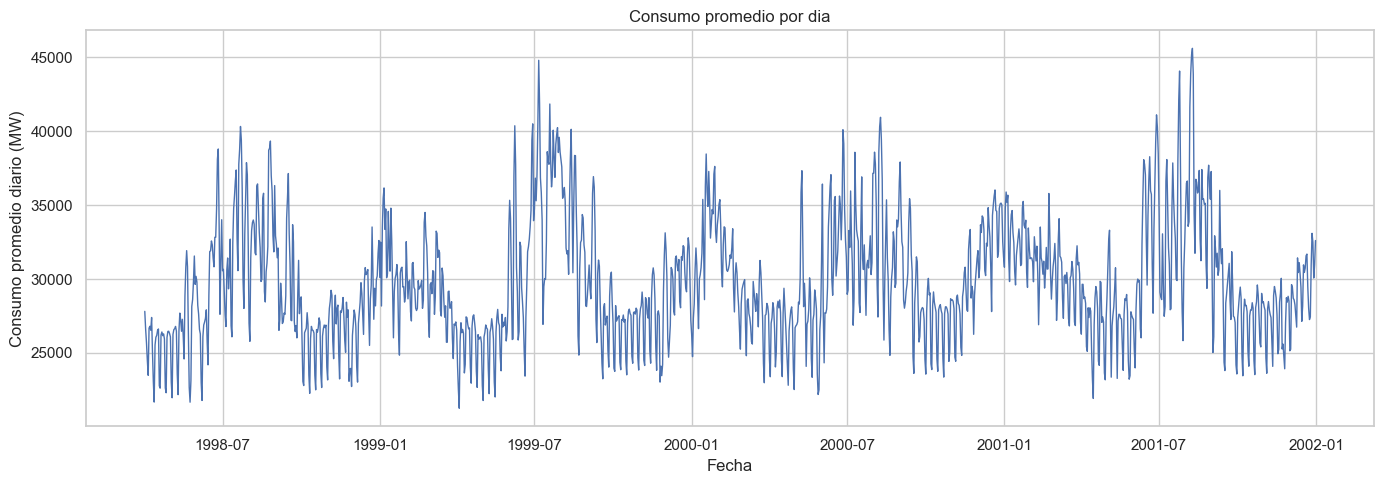

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(datos_diarios['fecha'], datos_diarios['consumo_promedio'], linewidth=1)
plt.title('Consumo promedio por dia')
plt.xlabel('Fecha')
plt.ylabel('Consumo promedio diario (MW)')
plt.tight_layout()
plt.show()


## 11. Normalizacion de variables

K-Means calcula distancias entre los datos. Por eso es importante normalizar las variables antes de entrenar el modelo.

Si una variable tiene valores mucho mas grandes que otra, puede dominar el calculo de distancia. Con `StandardScaler`, todas las variables quedan en una escala comparable.


In [13]:
scaler = StandardScaler()
X_normalizado = scaler.fit_transform(X)

X_normalizado = pd.DataFrame(X_normalizado, columns=variables_cluster)

display(X_normalizado.head())


,consumo_promedio,consumo_maximo,consumo_minimo,consumo_total,rango_consumo,desviacion_consumo,hora_pico
0,-0.481946,-0.582723,-0.877061,-0.764765,-0.119059,0.138756,0.852455
1,-0.780317,-0.769094,-1.123556,-0.776850,-0.187046,-0.019420,0.852455
2,-1.010886,-1.071663,-1.275551,-1.006881,-0.515649,-0.376586,0.852455
3,-1.303650,-1.204595,-1.226318,-1.298960,-0.762028,-0.666071,0.852455
4,-1.550537,-1.397052,-0.848975,-1.786437,-1.387855,-1.587517,1.161393


## 12. Seleccion del numero de clusters

Para elegir un numero adecuado de clusters se usa el metodo del codo. Este metodo entrena K-Means con diferentes valores de `k` y revisa la inercia.

La inercia mide que tan cerca quedan los datos de su centro de cluster. Se busca un punto donde agregar mas clusters ya no reduzca mucho la inercia.


In [14]:
inercias = []
valores_k = range(2, 11)

for k in valores_k:
    modelo_codo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo_codo.fit(X_normalizado)
    inercias.append(modelo_codo.inertia_)

tabla_codo = pd.DataFrame({
    'Numero de clusters': list(valores_k),
    'Inercia': inercias
})

display(tabla_codo)


,Numero de clusters,Inercia
0,2,5214.291093
1,3,3920.816976
2,4,3034.205259
3,5,2464.542331
4,6,2062.419341
5,7,1825.840304
6,8,1622.376708
7,9,1443.296933
8,10,1347.378667


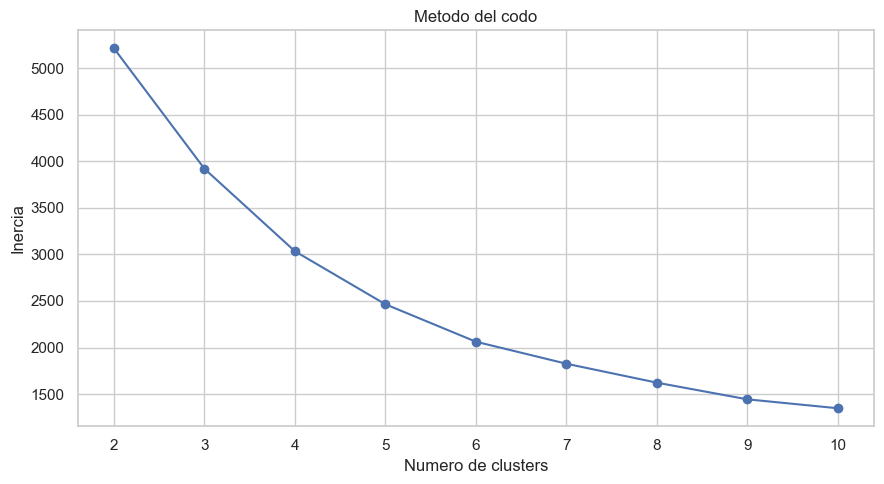

In [15]:
plt.figure(figsize=(9, 5))
plt.plot(list(valores_k), inercias, marker='o')
plt.title('Metodo del codo')
plt.xlabel('Numero de clusters')
plt.ylabel('Inercia')
plt.xticks(list(valores_k))
plt.tight_layout()
plt.show()


## 13. Entrenamiento del modelo K-Means

Con base en el metodo del codo y para facilitar la interpretacion en clase, se usa un modelo con 4 clusters.

La idea es obtener grupos que puedan interpretarse como consumo normal, alta demanda, bajo consumo y comportamiento atipico.


In [16]:
numero_clusters = 4

modelo_kmeans = KMeans(n_clusters=numero_clusters, random_state=42, n_init=10)
datos_diarios['Cluster'] = modelo_kmeans.fit_predict(X_normalizado)

display(datos_diarios[['fecha', 'consumo_promedio', 'consumo_maximo', 'Cluster']].head())


,fecha,consumo_promedio,consumo_maximo,Cluster
0,1998-04-01,27813.739130,31636.0,2
1,1998-04-02,26605.791667,30656.0,2
2,1998-04-03,25672.333333,29065.0,2
3,1998-04-04,24487.083333,28366.0,2
4,1998-04-05,23487.565217,27354.0,2


## 14. Evaluacion del agrupamiento

Para evaluar el agrupamiento se usa el **Silhouette Score**. Este valor ayuda a entender que tan bien separados quedaron los grupos.

En aprendizaje no supervisado no existe un porcentaje de precision igual al de un modelo supervisado, porque no hay una respuesta correcta para comparar. Por eso se muestra una **calidad aproximada del agrupamiento (%)**, calculada a partir del Silhouette Score.


In [17]:
silhouette = silhouette_score(X_normalizado, datos_diarios['Cluster'])
calidad_agrupamiento = max(0, silhouette) * 100

metricas_agrupamiento = pd.DataFrame({
    'Metrica': ['Silhouette Score', 'Calidad aproximada (%)'],
    'Valor': [silhouette, calidad_agrupamiento],
    'Interpretacion': [
        'Mide que tan separados quedaron los clusters.',
        'Porcentaje aproximado de separacion del agrupamiento.'
    ]
})

metricas_agrupamiento['Valor'] = metricas_agrupamiento['Valor'].round(4)
display(metricas_agrupamiento)

print(f'Calidad aproximada del agrupamiento: {calidad_agrupamiento:.2f}%.')


,Metrica,Valor,Interpretacion
0,Silhouette Score,0.3483,Mide que tan separados quedaron los clusters.
1,Calidad aproximada (%),34.8290,Porcentaje aproximado de separacion del agrupa...


Calidad aproximada del agrupamiento: 34.83%.


## 15. Analisis de resultados por cluster

Para interpretar los clusters, se revisan los valores promedio de cada grupo. La interpretacion no se asigna al azar: se comparan el consumo promedio, el consumo maximo y la variacion del consumo.


In [18]:
perfil_clusters = datos_diarios.groupby('Cluster')[variables_cluster].mean().round(2)
cantidad_por_cluster = datos_diarios['Cluster'].value_counts().sort_index()

perfil_clusters['cantidad_dias'] = cantidad_por_cluster

display(perfil_clusters)


,consumo_promedio,consumo_maximo,consumo_minimo,consumo_total,rango_consumo,desviacion_consumo,hora_pico,cantidad_dias
Cluster,,,,,,,,
0,31368.60,36396.53,24704.35,752846.39,11692.18,4057.46,17.86,461
1,27442.32,31042.49,21532.45,658615.58,9510.04,3427.59,11.69,235
2,26422.12,30702.89,20824.35,633664.62,9878.54,3393.29,19.63,470
3,36484.88,44242.70,26341.67,875637.12,17901.03,6529.92,16.72,205


In [19]:
orden_consumo = perfil_clusters['consumo_promedio'].sort_values()
cluster_bajo = orden_consumo.index[0]
cluster_alto = orden_consumo.index[-1]

candidatos_atipicos = perfil_clusters.drop(index=[cluster_bajo, cluster_alto], errors='ignore')

if len(candidatos_atipicos) > 0:
    cluster_atipico = candidatos_atipicos['desviacion_consumo'].idxmax()
else:
    cluster_atipico = perfil_clusters['desviacion_consumo'].idxmax()

nombres_cluster = {cluster: 'Consumo normal' for cluster in perfil_clusters.index}
nombres_cluster[cluster_bajo] = 'Bajo consumo'
nombres_cluster[cluster_alto] = 'Alta demanda'
nombres_cluster[cluster_atipico] = 'Comportamiento atipico'

datos_diarios['Nombre_cluster'] = datos_diarios['Cluster'].map(nombres_cluster)

interpretacion_clusters = perfil_clusters.copy()
interpretacion_clusters['Interpretacion'] = interpretacion_clusters.index.map(nombres_cluster)

display(interpretacion_clusters)


,consumo_promedio,consumo_maximo,consumo_minimo,consumo_total,rango_consumo,desviacion_consumo,hora_pico,cantidad_dias,Interpretacion
Cluster,,,,,,,,,
0,31368.60,36396.53,24704.35,752846.39,11692.18,4057.46,17.86,461,Comportamiento atipico
1,27442.32,31042.49,21532.45,658615.58,9510.04,3427.59,11.69,235,Consumo normal
2,26422.12,30702.89,20824.35,633664.62,9878.54,3393.29,19.63,470,Bajo consumo
3,36484.88,44242.70,26341.67,875637.12,17901.03,6529.92,16.72,205,Alta demanda


## 16. Interpretacion de los clusters

La tabla anterior permite explicar cada grupo de forma sencilla:

- **Alta demanda**: cluster con mayor consumo promedio diario.
- **Bajo consumo**: cluster con menor consumo promedio diario.
- **Comportamiento atipico**: cluster con alta variacion interna de consumo.
- **Consumo normal**: dias con valores intermedios y comportamiento mas estable.

Esta interpretacion puede cambiar si se entrena el modelo con nuevos datos, porque K-Means encuentra grupos segun la estructura del dataset disponible.


## 17. Grafica de dispersion por cluster

Esta grafica compara el consumo promedio contra el consumo maximo. Cada color representa un cluster asignado por K-Means.


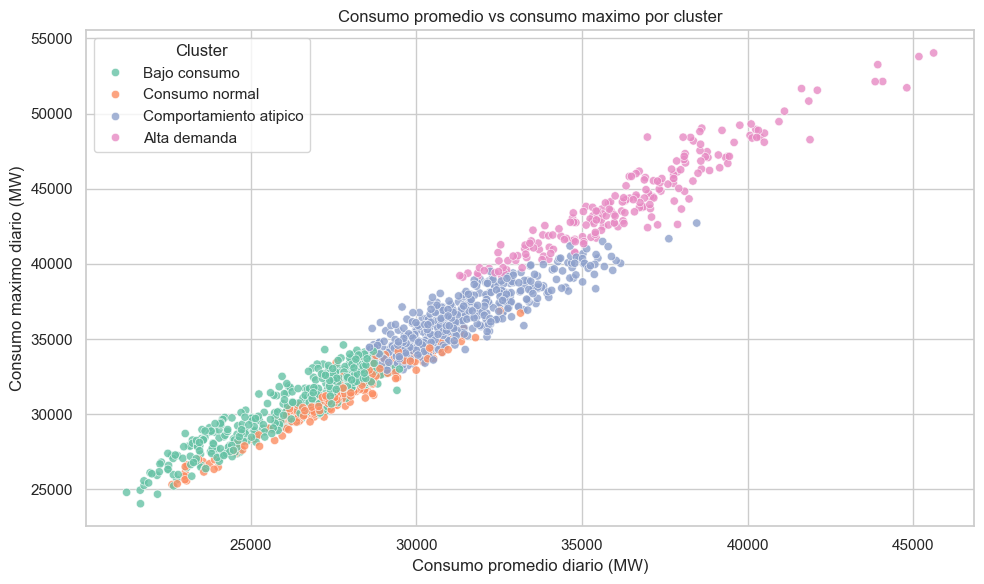

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=datos_diarios,
    x='consumo_promedio',
    y='consumo_maximo',
    hue='Nombre_cluster',
    palette='Set2',
    alpha=0.8
)
plt.title('Consumo promedio vs consumo maximo por cluster')
plt.xlabel('Consumo promedio diario (MW)')
plt.ylabel('Consumo maximo diario (MW)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


## 18. Promedio de consumo por cluster

La siguiente grafica muestra el consumo promedio diario de cada grupo. Esto facilita identificar grupos de alta y baja demanda.


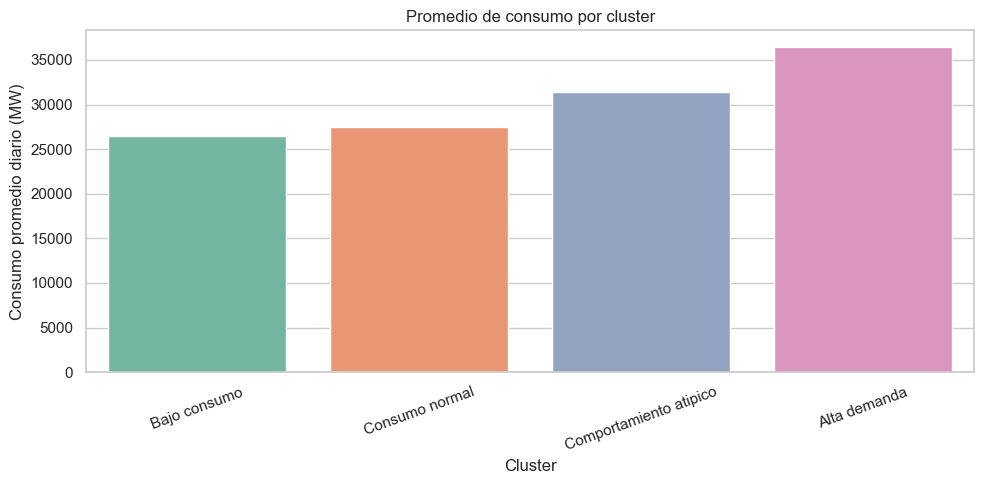

In [21]:
promedio_cluster = datos_diarios.groupby('Nombre_cluster')['consumo_promedio'].mean().sort_values()

plt.figure(figsize=(10, 5))
sns.barplot(x=promedio_cluster.index, y=promedio_cluster.values, palette='Set2', hue=promedio_cluster.index, legend=False)
plt.title('Promedio de consumo por cluster')
plt.xlabel('Cluster')
plt.ylabel('Consumo promedio diario (MW)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 19. Cantidad de dias por cluster

Esta grafica muestra cuantos dias quedaron en cada grupo. Si un cluster tiene pocos dias, puede representar un comportamiento menos frecuente.


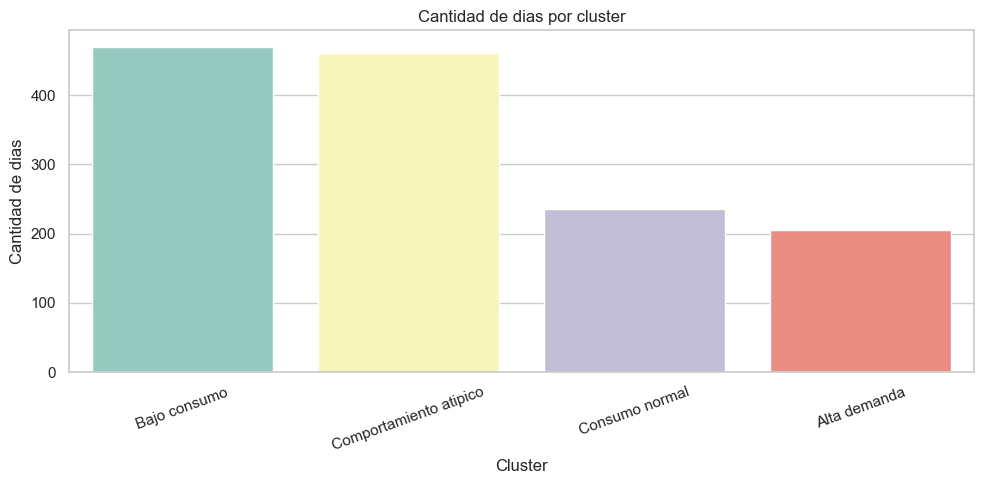

In [22]:
conteo_cluster = datos_diarios['Nombre_cluster'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=conteo_cluster.index, y=conteo_cluster.values, palette='Set3', hue=conteo_cluster.index, legend=False)
plt.title('Cantidad de dias por cluster')
plt.xlabel('Cluster')
plt.ylabel('Cantidad de dias')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 20. Serie temporal con clusters asignados

Esta grafica permite ver como cambian los grupos a lo largo del tiempo. Cada punto representa un dia y su color indica el cluster asignado.


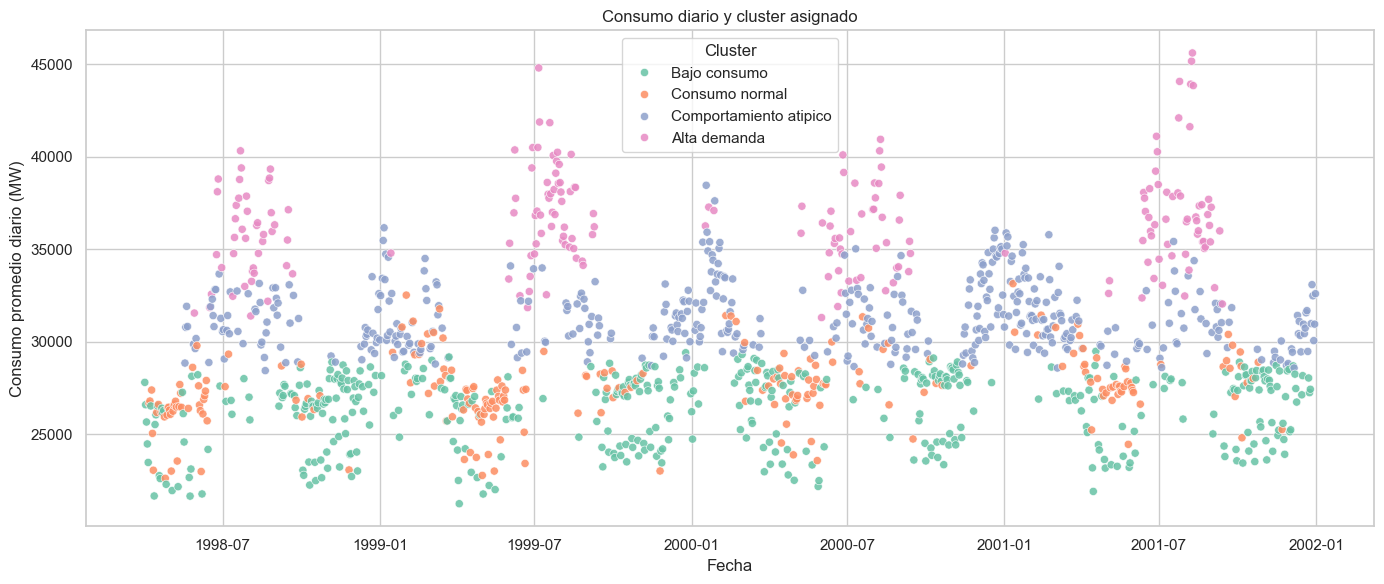

In [23]:
plt.figure(figsize=(14, 6))
sns.scatterplot(
    data=datos_diarios,
    x='fecha',
    y='consumo_promedio',
    hue='Nombre_cluster',
    palette='Set2',
    s=35,
    alpha=0.85
)
plt.title('Consumo diario y cluster asignado')
plt.xlabel('Fecha')
plt.ylabel('Consumo promedio diario (MW)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


## 21. Ejemplos de dias por cluster

Para entender mejor los resultados, se muestran algunos dias representativos de cada cluster.


In [24]:
ejemplos_cluster = datos_diarios.sort_values(['Cluster', 'fecha']).groupby('Nombre_cluster').head(5)

columnas_ejemplo = [
    'fecha',
    'Nombre_cluster',
    'consumo_promedio',
    'consumo_maximo',
    'consumo_minimo',
    'rango_consumo',
    'desviacion_consumo',
    'hora_pico'
]

display(ejemplos_cluster[columnas_ejemplo])


,fecha,Nombre_cluster,consumo_promedio,consumo_maximo,consumo_minimo,rango_consumo,desviacion_consumo,hora_pico
47,1998-05-18,Comportamiento atipico,28856.208333,34730.0,19668.0,15062.0,5641.741066,17
48,1998-05-19,Comportamiento atipico,30789.916667,37137.0,21224.0,15913.0,5897.106379,17
49,1998-05-20,Comportamiento atipico,31921.625000,39000.0,22331.0,16669.0,6023.049457,17
50,1998-05-21,Comportamiento atipico,30832.416667,36273.0,23022.0,13251.0,4730.272360,14
57,1998-05-28,Comportamiento atipico,29879.291667,36060.0,20676.0,15384.0,5699.619160,17
5,1998-04-06,Consumo normal,26679.666667,30229.0,20535.0,9694.0,3504.012689,11
6,1998-04-07,Consumo normal,26805.833333,29946.0,21211.0,8735.0,3143.186761,9
8,1998-04-09,Consumo normal,27400.250000,31017.0,20029.0,10988.0,4271.036910,12
9,1998-04-10,Consumo normal,25057.833333,28324.0,21150.0,7174.0,2250.561721,11
10,1998-04-11,Consumo normal,23067.875000,25574.0,20075.0,5499.0,1777.210377,11


## 22. Conclusion

El modelo logro separar los dias segun patrones de consumo energetico. Al analizar variables diarias como consumo promedio, consumo maximo, consumo minimo, consumo total, rango, desviacion y hora pico, K-Means encontro grupos con comportamientos similares.

Este enfoque puede ayudar a detectar dias de alta demanda, dias de consumo normal, dias de bajo consumo y posibles comportamientos atipicos dentro del sistema PJM.

Al ser aprendizaje no supervisado, el modelo no predice un valor exacto ni usa una respuesta correcta. Su funcion es descubrir grupos ocultos en los datos para apoyar el analisis y la toma de decisiones.


## 23. Diferencia con el proyecto anterior

En el proyecto anterior se usaba aprendizaje supervisado. Ese enfoque buscaba predecir un valor objetivo de consumo energetico usando una red neuronal.

En este nuevo proyecto se usa aprendizaje no supervisado. Aqui no se usa una variable objetivo ni etiquetas previas. El modelo agrupa datos parecidos y permite descubrir patrones de comportamiento energetico.

- **Antes**: se predecia un valor de consumo.
- **Ahora**: se agrupan dias con patrones similares.
